In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

#data collection
data_path = "StudentPerformanceFactors.csv"
df = pd.read_csv(data_path)
print("\nDataset Loaded Successfully")
print("Dataset Shape:", df.shape)
print("Columns:\n", df.columns)


Dataset Loaded Successfully
Dataset Shape: (6607, 20)
Columns:
 Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')


In [6]:
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

In [7]:
#deal with missing values
cat_cols_with_na = ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]

for col in cat_cols_with_na:
    X[col].fillna(X[col].mode()[0], inplace=True)

/tmp/ipykernel_5333/2565275508.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mode()[0], inplace=True)


In [18]:
#feature engineering
X["Study_Efficiency"] = X["Hours_Studied"] * X["Previous_Scores"]
X["Wellness"] = X["Sleep_Hours"] * X["Physical_Activity"]
X["Study_Intensity"] = X["Hours_Studied"] / (X["Sleep_Hours"] + 1)
X["Attendance_Study_Balance"] = X["Attendance"] * X["Hours_Studied"]
X["Score_Consistency"] = X["Previous_Scores"] - X["Hours_Studied"]
X["Risk_Factor"] = (
    (X["Learning_Disabilities_Yes"]) +
    (X["Access_to_Resources_Low"]) +
    (X["Parental_Involvement_Low"])
)
X["Motivation_Adjusted_Study"] = X["Hours_Studied"] * (
    1 + (X["Motivation_Level_High"] - X["Motivation_Level_Low"])
)

KeyError: 'Motivation_Level_High'

In [19]:
#one hot encoding of variables
X = pd.get_dummies(X, drop_first=True)

In [20]:
#train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
#standardise
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)
print(X.columns[:10])

(6607, 33)
(5285, 33)
(1322, 33)
Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Study_Efficiency',
       'Wellness', 'Parental_Involvement_Low', 'Parental_Involvement_Medium'],
      dtype='object')


In [23]:
processed_df = X.copy()
processed_df["Exam_Score"] = y  # optional (only if needed for analysis)

processed_df.to_csv("processed_student_data.csv", index=False)

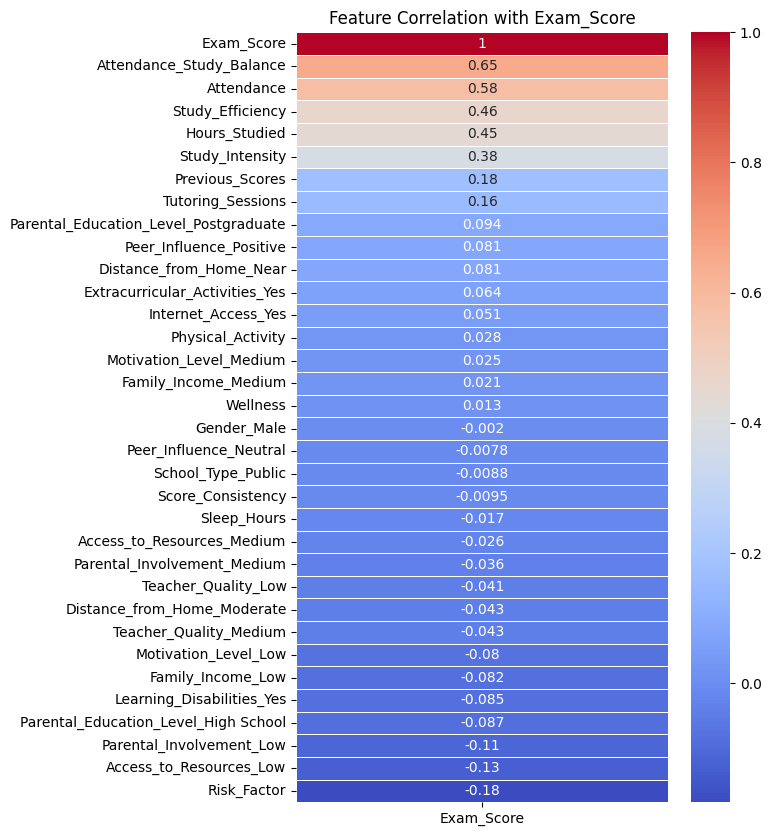

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# combine X and target
df_corr = X.copy()
df_corr["Exam_Score"] = y

# compute correlation matrix
corr_matrix = df_corr.corr()

# extract correlations with target only
target_corr = corr_matrix[["Exam_Score"]].sort_values(by="Exam_Score", ascending=False)

# plot heatmap
plt.figure(figsize=(6, 10))
sns.heatmap(target_corr, annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Feature Correlation with Exam_Score")
plt.show()